# 01 - Comprendre une table entrées-sorties multirégionale

Ce notebook présente le cœur économique d’EXIOBASE. À la fin, vous saurez :

- repérer les régions, les industries et les catégories de demande finale ;
- lire les matrices $Z$, $A$ et $Y$, ainsi que le vecteur $x$ ;
- vérifier l’équilibre comptable d’une table entrées-sorties ;
- distinguer les besoins directs des besoins directs et indirects décrits par l’inverse de Leontief $L$.

> Nous étudions ici uniquement les flux économiques. Leur connexion aux émissions et aux ressources naturelles sera introduite dans le notebook `02`.

## 1. Charger la table préparée dans le notebook 00

Le notebook est autonome : il recharge l’archive EXIOBASE plutôt que de dépendre de l’état d’un autre notebook. Il faut toutefois avoir téléchargé et vérifié cette archive avec `00_préparer_EXIOBASE.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymrio as mr

ANNEE = 2022
SYSTEME = "ixi"
DOSSIER_EXIOBASE = Path("D:/EXIOBASE/3.10.2")
ARCHIVE_EXIOBASE = DOSSIER_EXIOBASE / f"IOT_{ANNEE}_{SYSTEME}.zip"

if not ARCHIVE_EXIOBASE.exists():
    raise FileNotFoundError(
        f"Archive absente : {ARCHIVE_EXIOBASE}. "
        "Exécutez d’abord le notebook 00_préparer_EXIOBASE.ipynb."
    )

print(f"Archive utilisée : {ARCHIVE_EXIOBASE}")

Archive utilisée : D:\EXIOBASE\3.10.2\IOT_2022_ixi.zip


In [2]:
io = mr.parse_exiobase3(path=ARCHIVE_EXIOBASE)
print("Table EXIOBASE chargée.")

Table EXIOBASE chargée.


L’archive contient notamment les transactions $Z$, la demande finale $Y$ et la production $x$. PyMRIO peut en déduire les coefficients techniques $A$ et l’inverse de Leontief $L$.

Nous utilisons `calc_system()` plutôt que `calc_all()` : seules les matrices économiques nécessaires dans ce notebook sont calculées. Les extensions environnementales peuvent donc attendre le notebook `02`.

In [3]:
_ = io.calc_system()
print("Matrices économiques calculées.")

Matrices économiques calculées.


## 2. Vue d’ensemble du système

Une table entrées-sorties décrit simultanément :

| Symbole | Objet PyMRIO | Contenu | Unité |
|---|---|---|---|
| $x$ | `io.x` | production totale de chaque couple région-industrie | million d’euros |
| $Z$ | `io.Z` | transactions intermédiaires entre industries | million d’euros |
| $A$ | `io.A` | intrants directs nécessaires par unité de production | euro par euro |
| $Y$ | `io.Y` | demande finale des ménages, administrations, investissements, etc. | million d’euros |
| $L$ | `io.L` | production directe et indirecte requise par unité de demande finale | euro par euro |

Dans $Z$ et $A$, une **ligne** indique *qui fournit* et une **colonne** *qui utilise*. La cellule $(i,j)$ représente donc un flux de l’activité $i$ vers l’activité $j$.

### Régions, industries et demande finale

Chaque activité économique est identifiée par deux niveaux d’index : une région et une industrie. Avec 49 régions et 163 industries, les grandes matrices carrées comportent $49 \times 163 = 7\,987$ lignes et autant de colonnes.

In [4]:
regions = list(io.get_regions())
secteurs = list(io.get_sectors())
categories_demande = list(io.get_Y_categories())
unites_monetaires = list(io.unit["unit"].unique())

pd.Series(
    {
        "régions": len(regions),
        "industries": len(secteurs),
        "activités région-industrie": len(io.x),
        "catégories de demande finale": len(categories_demande),
        "dimensions de Z": str(io.Z.shape),
        "unité monétaire": ", ".join(unites_monetaires),
    },
    name="Structure",
)

régions                                   49
industries                               163
activités région–industrie              7987
catégories de demande finale               7
dimensions de Z                 (7987, 7987)
unité monétaire                        M.EUR
Name: Structure, dtype: object

In [5]:
pd.DataFrame(
    {
        "quelques régions": pd.Series(regions[:5] + regions[-5:]),
        "quelques industries": pd.Series(secteurs[:10]),
        "catégories de demande finale": pd.Series(categories_demande),
    }
)

,quelques régions,quelques industries,catégories de demande finale
0,AT,Cultivation of paddy rice,Final consumption expenditure by households
1,BE,Cultivation of wheat,Final consumption expenditure by non-profit or...
2,BG,Cultivation of cereal grains nec,Final consumption expenditure by government
3,CY,"Cultivation of vegetables, fruit, nuts",Gross fixed capital formation
4,CZ,Cultivation of oil seeds,Changes in inventories
5,WA,"Cultivation of sugar cane, sugar beet",Changes in valuables
6,WL,Cultivation of plant-based fibers,Exports: Total (fob)
7,WE,Cultivation of crops nec,NaN
8,WF,Cattle farming,NaN
9,WM,Pigs farming,NaN


## 3. Le vecteur de production $x$

Le vecteur $x$ contient la production annuelle de chaque industrie dans chaque région. Prenons l’élevage bovin français comme fil conducteur. Le couple `("FR", "Cattle farming")` désigne à la fois une ligne et, dans les matrices carrées, une colonne.

In [6]:
ACTIVITE = ("FR", "Cattle farming")
production = io.x.loc[ACTIVITE, "indout"]

pd.Series(
    {
        "production (millions d’euros)": production,
        "production (milliards d’euros)": production / 1_000,
    },
    name=f"{ACTIVITE[1]} : {ACTIVITE[0]}, {ANNEE}",
)

production (millions d’euros)     9829.190976
production (milliards d’euros)       9.829191
Name: Cattle farming — FR — 2022, dtype: float64

## 4. Les transactions intermédiaires $Z$

La *colonne* d’une activité décrit ses *achats* auprès de toutes les activités du monde. Elle peut être lue comme une « recette de production » exprimée en valeur monétaire.

La cellule suivante affiche les dix principaux intrants de l’élevage bovin français. Leur somme représente l’ensemble de ses consommations intermédiaires.

In [8]:
achats_intermediaires = io.Z[ACTIVITE]
principaux_achats = achats_intermediaires.nlargest(10).rename("millions d’euros")
principaux_achats.to_frame()

millions d’euros
region sector                                                              
FR     Processing of Food products nec                          2422.932993
       Manufacture of beverages                                  918.378485
       Cultivation of cereal grains nec                          760.409732
       Other business activities (74)                            321.477024
       Cultivation of wheat                                      286.350552
       Manufacture of gas; distribution of gaseous fue...        221.056626
       Insurance and pension funding, except compulsor...        213.226074
       Public administration and defence; compulsory s...        191.700756
       Petroleum Refinery                                        164.883717
       Manufacture of fish products                              156.726131

In [9]:
total_achats_intermediaires = achats_intermediaires.sum()
solde_primaire = production - total_achats_intermediaires

pd.Series(
    {
        "production": production,
        "consommations intermédiaires": total_achats_intermediaires,
        "solde correspondant aux facteurs primaires": solde_primaire,
    },
    name="millions d’euros",
)

production                                    9829.190976
consommations intermédiaires                  9122.104655
solde correspondant aux facteurs primaires     707.086320
Name: millions d’euros, dtype: float64

La production ne se résume pas aux achats intermédiaires : le solde rémunère les facteurs primaires et comprend notamment les salaires, les impôts nets et l’excédent d’exploitation. Sa composition détaillée se trouve dans l’extension `factor_inputs`, qui sera étudiée avec les autres extensions.

Réciproquement, une **ligne** de $Z$ indique quelles activités achètent la production intermédiaire de l’activité étudiée.

In [10]:
ventes_intermediaires = io.Z.loc[ACTIVITE, :]
ventes_intermediaires.nlargest(10).rename("millions d’euros").to_frame()

millions d’euros
region sector                                                              
FR     Processing of meat cattle                                6366.952353
       Processing of dairy products                              974.376883
IT     Processing of meat cattle                                 746.588590
ES     Processing of meat cattle                                 151.005004
FR     Production of meat products nec                            86.974324
       Tanning and dressing of leather; manufacture of...         71.173729
       Manufacture of rubber and plastic products (25)            47.764312
WF     Chemicals nec                                              41.250270
       Real estate activities (70)                                35.634547
WM     Processing of meat cattle                                  24.468967

Sans grande surprise, c'est l'industrie agro-alimentaire française, notamment les abattoirs et l'industrie laitière, qui est le principal client de l'élevage bovin français. L'Italie et l'Espagne sont également des partenaires majeurs de ce secteur.

## 5. Les coefficients techniques $A$

Les valeurs de $Z$ dépendent de la taille des industries. Pour comparer leurs recettes de production, chaque colonne $j$ est divisée par la production $x_j$ correspondante :

$$a_{ij} = \frac{z_{ij}}{x_j}$$

Un coefficient $a_{ij}=0{,}10$ signifie que produire un euro dans l’activité $j$ nécessite directement 0,10 euro provenant de l’activité $i$.

In [12]:
coefficients_directs = io.A[ACTIVITE]
coefficients_recalcules = achats_intermediaires / production

assert np.allclose(coefficients_directs, coefficients_recalcules, equal_nan=True)
coefficients_directs.nlargest(10).rename("euro par euro produit").to_frame()

euro par euro produit
region sector                                                                   
FR     Processing of Food products nec                                  0.246504
       Manufacture of beverages                                         0.093434
       Cultivation of cereal grains nec                                 0.077362
       Other business activities (74)                                   0.032706
       Cultivation of wheat                                             0.029133
       Manufacture of gas; distribution of gaseous fue...               0.022490
       Insurance and pension funding, except compulsor...               0.021693
       Public administration and defence; compulsory s...               0.019503
       Petroleum Refinery                                               0.016775
       Manufacture of fish products                                     0.015945

## 6. La demande finale $Y$

Toutes les productions ne sont pas revendues à d’autres industries. Une partie répond à une demande finale : consommation des ménages, administrations publiques, organismes sans but lucratif, investissement ou variation des stocks. C'est même cette demande fniale qui est considérée comme pilotant tout le reste, dans l'approche de Leontief (qu'on verra plus loin), toute l'économie _produit pour_ la demande finale.

Les lignes de $Y$ identifient le lieu et l’industrie de **production**. Ses colonnes identifient la région et la catégorie de **demande finale**. La consommation française peut donc mobiliser des productions françaises ou importées.

In [13]:
CATEGORIE_MENAGES = "Final consumption expenditure by households"
demande_menages_fr = io.Y[("FR", CATEGORIE_MENAGES)]

demande_menages_fr.nlargest(15).rename("millions d’euros").to_frame()

millions d’euros
region sector                                                              
FR     Real estate activities (70)                            130849.380539
       Hotels and restaurants (55)                            120241.547535
       Other land transport                                    98820.868915
       Retail trade, except of motor vehicles and moto...      88973.658553
       Sale, maintenance, repair of motor vehicles, mo...      74235.256575
       Insurance and pension funding, except compulsor...      52336.330022
       Health and social work (85)                             49528.074549
       Transport via railways                                  41141.610638
       Processing of Food products nec                         36808.564184
       Manufacture of motor vehicles, trailers and sem...      31895.563548
       Air transport (62)                                      28742.324099
       Financial intermediation, except insurance and ...      25943.260229
       Manufacture of gas; distribution of gaseous fue...      25846.727218
       Petroleum Refinery                                      20244.321669
       Processing of dairy products                            18753.483180

In [14]:
origine_demande_menages_fr = (
    demande_menages_fr.groupby(level="region").sum().sort_values(ascending=False)
)
origine_demande_menages_fr.head(10).rename("millions d’euros").to_frame()

,millions d’euros
region,
FR,1.046809e+06
DE,3.843623e+04
ES,3.095179e+04
IT,2.293503e+04
BE,2.186714e+04
GB,1.815397e+04
CN,1.734801e+04
WF,1.580496e+04
NL,1.516674e+04


## 7. Vérifier l’équilibre comptable

Pour chaque activité, la production est vendue soit à une autre activité, soit à la demande finale :

$$x = Z\mathbf{1} + Y\mathbf{1}$$

Les vecteurs $\mathbf{1}$ étant des colonnes de taille appropriée, remplies uniquement de la valeur 1.

Autrement dit, la somme de chaque ligne de $Z$ et de chaque ligne de $Y$ doit reconstituer $x$. Ce contrôle est simple mais essentiel avant toute analyse.

In [17]:
production_reconstituee = io.Z.sum(axis=1) + io.Y.sum(axis=1)
production_observee = io.x["indout"]
ecart = production_reconstituee - production_observee

assert np.allclose(production_reconstituee, production_observee)
pd.Series(
    {
        "production reconstituée (milliards d’euros)": production_reconstituee.sum() / 1_000,
        "production observée (milliards d’euros)": production_observee.sum() / 1_000,
        "écart absolu maximal (millions d’euros)": ecart.abs().max(),
    },
    name="Contrôle de l’équilibre",
)

production reconstituée (milliards d’euros)    199312.460367
production observée (milliards d’euros)        199312.460367
écart absolu maximal (millions d’euros)             0.000007
Name: Contrôle de l’équilibre, dtype: float64

La somme totale de la production économique (intermédiaire et finale) mondiale est d'environ 200000 milliards d’euros en 2022.

ATTENTION : cette production totale n'est pas le PIB !

Le PIB équivaut (entre autres) à la somme totale des consommations, donc de la demande finale.

In [24]:
pib_mondial = io.Y.sum().sum() / 1000
print(f"PIB mondial (milliards d’euros) : {pib_mondial:,.0f}")

PIB mondial (milliards d’euros) : 95,760


Il est possible de vérifier que la somme de la consommation mondiale concorde avec le PIB mondial officiel d'environ 105000 milliards de dollars en 2022 (source : https://data.worldbank.org/indicator/NY.GDP.MKTP.CD).

## 8. Des besoins directs aux besoins totaux : l’inverse de Leontief

Puisque $Z = A\hat{x}$, l’équilibre précédent peut s’écrire :

$$x = Ax + y$$

où $y$ représente la demande finale agrégée. On en déduit :

$$x = (I-A)^{-1}y = Ly$$

$A$ décrit le premier rang de fournisseurs. $A^2$ décrit les fournisseurs des fournisseurs, puis $A^3$ le rang suivant, etc. L’inverse de Leontief rassemble tous ces rangs :

$$L = I + A + A^2 + A^3 + \dots$$

Ainsi, la colonne $j$ de $L$ donne toute la production mobilisée dans le monde par un euro supplémentaire de demande finale adressée à l’activité $j$.

### Exemple : le ciment nécessaire à la construction française

La construction utilise directement du ciment. Elle mobilise aussi indirectement du ciment à travers ses autres fournisseurs : fabrication de matériaux, énergie, transport, services, etc. Comparons les coefficients de $A$ et de $L$ pour le ciment produit dans chaque région.

In [25]:
ACTIVITE_CONSTRUCTION = ("FR", "Construction (45)")
SECTEUR_CIMENT = "Manufacture of cement, lime and plaster"
selection = (pd.IndexSlice[:, SECTEUR_CIMENT], ACTIVITE_CONSTRUCTION)

besoins_ciment = pd.DataFrame(
    {
        "directs": io.A.loc[selection],
        "directs et indirects": io.L.loc[selection],
    }
)
besoins_ciment["indirects"] = (
    besoins_ciment["directs et indirects"] - besoins_ciment["directs"]
)
besoins_ciment = besoins_ciment.nlargest(10, "directs et indirects")
besoins_ciment[["directs", "indirects"]]

,,directs,indirects
region,sector,,
FR,"Manufacture of cement, lime and plaster",0.057945,0.024577
ES,"Manufacture of cement, lime and plaster",0.000748,0.001392
BE,"Manufacture of cement, lime and plaster",0.000868,0.001142
DE,"Manufacture of cement, lime and plaster",0.000518,0.000658
IT,"Manufacture of cement, lime and plaster",0.000302,0.000455
WM,"Manufacture of cement, lime and plaster",0.000192,0.000234
WF,"Manufacture of cement, lime and plaster",0.000184,0.000196
NL,"Manufacture of cement, lime and plaster",0.000135,0.000238
WA,"Manufacture of cement, lime and plaster",0.000177,0.000189


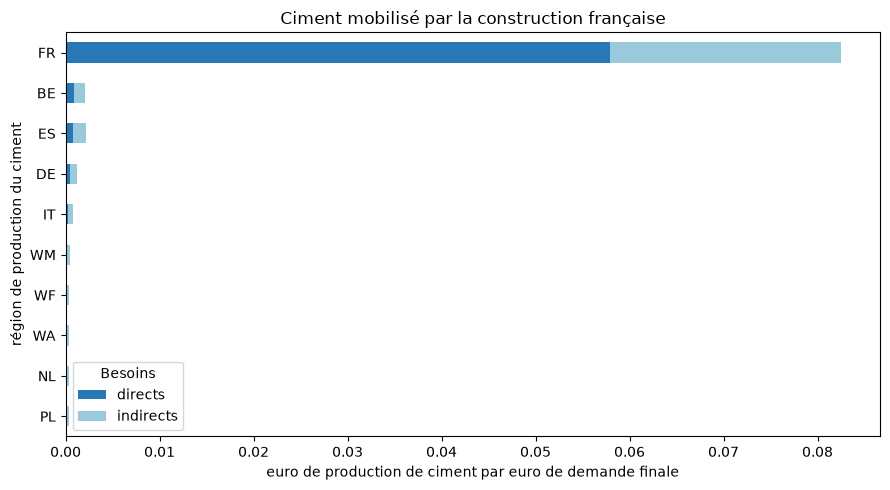

In [26]:
donnees_graphique = besoins_ciment[["directs", "indirects"]].copy()
donnees_graphique.index = donnees_graphique.index.get_level_values("region")

ax = donnees_graphique.sort_values("directs").plot.barh(
    stacked=True, figsize=(9, 5), color=["#2878B5", "#9AC9DB"]
)
ax.set(
    title="Ciment mobilisé par la construction française",
    xlabel="euro de production de ciment par euro de demande finale",
    ylabel="région de production du ciment",
)
ax.legend(title="Besoins")
plt.tight_layout()

## 9. Une lecture alternative : les couches successives de production

L’inverse de Leontief peut aussi être compris sans commencer par une inversion de matrice. Imaginons une demande finale de 1 million d’euros adressée à la construction française :

- la couche 0 est cette production initiale, décrite par $y$ ;
- la couche 1 contient la production des fournisseurs directs, soit $Ay$ ;
- la couche 2 contient la production nécessaire aux fournisseurs, soit $A^2y$ ;
- les couches suivantes répètent le même raisonnement.

La somme après $n$ couches est donc :

$$y + Ay + A^2y + \dots + A^ny$$

Lorsque le nombre de couches augmente, cette somme converge vers $Ly=(I-A)^{-1}y$. Ces couches sont des vagues de propagation comptable. Elles ne correspondent pas toujours à des fournisseurs physiques parfaitement distincts, car une même industrie peut réapparaître dans plusieurs couches.

In [ ]:
NOMBRE_COUCHES = 6

demande_initiale = pd.Series(0.0, index=io.A.index, name="demande finale")
demande_initiale.loc[ACTIVITE_CONSTRUCTION] = 1.0

vecteur_couche = demande_initiale.copy()
vecteurs_couches = []
for numero_couche in range(NOMBRE_COUCHES + 1):
    vecteurs_couches.append(vecteur_couche)
    vecteur_couche = io.A @ vecteur_couche

production_par_couche = pd.Series(
    [vecteur.sum() for vecteur in vecteurs_couches],
    index=["Demande finale"]
    + [f"Couche {numero}" for numero in range(1, NOMBRE_COUCHES + 1)],
    name="production ajoutée",
)
production_cumulee = production_par_couche.cumsum()
production_totale_leontief = (io.L @ demande_initiale).sum()

convergence_couches = pd.DataFrame(
    {
        "production ajoutée": production_par_couche,
        "production cumulée": production_cumulee,
        "part du total de Leontief": (
            production_cumulee / production_totale_leontief
        ),
    }
)
convergence_couches

In [ ]:
positions_couches = np.arange(len(production_par_couche))
bases_couches = np.r_[0, production_cumulee.iloc[:-1].to_numpy()]
position_total = len(production_par_couche) + 0.7

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    positions_couches,
    production_par_couche,
    bottom=bases_couches,
    color="#2878B5",
    edgecolor="white",
    label="Production ajoutée par chaque couche",
)
ax.bar(
    position_total,
    production_totale_leontief,
    color="#E67E22",
    label="Total obtenu avec $Ly$",
)
ax.axhline(
    production_totale_leontief,
    color="#E67E22",
    linestyle=":",
    linewidth=1.5,
)

for position, valeur_cumulee in zip(positions_couches, production_cumulee):
    ax.text(
        position,
        valeur_cumulee,
        f"{valeur_cumulee:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.text(
    position_total,
    production_totale_leontief,
    f"{production_totale_leontief:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
)

ax.set_xticks(
    list(positions_couches) + [position_total],
    list(production_par_couche.index) + ["Total avec $Ly$"],
)
ax.set(
    title=(
        "Production mondiale mobilisée par 1 million d’euros "
        "de demande finale de construction française"
    ),
    ylabel="millions d’euros de production cumulée",
    xlabel="propagation dans la chaîne d’approvisionnement",
)
ax.legend()
plt.tight_layout()

Le diagramme se lit comme une cascade. Chaque barre bleue ajoute la production d’une couche à la somme des couches précédentes. La barre orange donne la production totale calculée directement avec l’inverse de Leontief. L’écart encore visible après la sixième couche correspond à la contribution des couches suivantes.

### Bonus : où et dans quelles industries les couches se développent-elles ?

Le graphique précédent montre le montant ajouté par chaque couche. Le graphique bonus décompose maintenant chaque montant selon deux dimensions :

- le bleu foncé représente la production située en France et le bleu clair la production située hors de France ;
- le remplissage plein représente la construction et les hachures les autres industries.

La demande initiale reste entièrement dans la construction française. Les couches suivantes se diffusent progressivement vers d’autres industries et d’autres régions. Ce découpage localise la production mobilisée. Il ne mesure pas directement des échanges bilatéraux entre pays.

In [ ]:
from matplotlib.patches import Patch

regions_index = io.A.index.get_level_values("region")
secteurs_index = io.A.index.get_level_values("sector")
est_francais = regions_index == "FR"
est_construction = secteurs_index == "Construction (45)"

masques_categories = {
    "France, construction": est_francais & est_construction,
    "France, autres industries": est_francais & ~est_construction,
    "Hors de France, construction": ~est_francais & est_construction,
    "Hors de France, autres industries": ~est_francais & ~est_construction,
}
styles_categories = {
    "France, construction": ("#2878B5", ""),
    "France, autres industries": ("#2878B5", "///"),
    "Hors de France, construction": ("#9AC9DB", ""),
    "Hors de France, autres industries": ("#9AC9DB", "///"),
}

decomposition_couches = pd.DataFrame(
    {
        categorie: [vecteur.loc[masque].sum() for vecteur in vecteurs_couches]
        for categorie, masque in masques_categories.items()
    },
    index=production_par_couche.index,
)
vecteur_total_leontief = io.L @ demande_initiale
decomposition_totale = pd.Series(
    {
        categorie: vecteur_total_leontief.loc[masque].sum()
        for categorie, masque in masques_categories.items()
    }
)

assert np.allclose(decomposition_couches.sum(axis=1), production_par_couche)
assert np.isclose(decomposition_totale.sum(), production_totale_leontief)

fig, ax = plt.subplots(figsize=(12, 6))
empilement_couches = np.zeros(len(decomposition_couches))
for categorie in decomposition_couches.columns:
    couleur, hachures = styles_categories[categorie]
    valeurs = decomposition_couches[categorie].to_numpy()
    ax.bar(
        positions_couches,
        valeurs,
        bottom=bases_couches + empilement_couches,
        color=couleur,
        hatch=hachures,
        edgecolor="white",
    )
    empilement_couches += valeurs

base_total = 0.0
for categorie, valeur in decomposition_totale.items():
    couleur, hachures = styles_categories[categorie]
    ax.bar(
        position_total,
        valeur,
        bottom=base_total,
        color=couleur,
        hatch=hachures,
        edgecolor="white",
    )
    base_total += valeur
ax.bar(
    position_total,
    production_totale_leontief,
    facecolor="none",
    edgecolor="#E67E22",
    linewidth=2.5,
)
ax.axhline(
    production_totale_leontief, color="#E67E22", linestyle=":", linewidth=1.5
)

for position, valeur_cumulee in zip(positions_couches, production_cumulee):
    ax.text(
        position, valeur_cumulee, f"{valeur_cumulee:.2f}",
        ha="center", va="bottom", fontsize=9
    )
ax.text(
    position_total, production_totale_leontief, f"{production_totale_leontief:.2f}",
    ha="center", va="bottom", fontsize=9
)

ax.set_xticks(
    list(positions_couches) + [position_total],
    list(decomposition_couches.index) + ["Total avec $Ly$"],
)
ax.set(
    title="Décomposition géographique et sectorielle des couches de production",
    ylabel="millions d’euros de production cumulée",
    xlabel="propagation dans la chaîne d’approvisionnement",
)
ax.legend(
    handles=[
        Patch(
            facecolor=styles_categories[categorie][0],
            hatch=styles_categories[categorie][1],
            edgecolor="white",
            label=categorie,
        )
        for categorie in decomposition_couches.columns
    ],
    loc="upper left",
)
plt.tight_layout()

## 10. À vous de lire une activité

La cellule suivante résume une activité choisie. Modifiez `PAYS_ETUDIE` et `SECTEUR_ETUDIE`, puis répondez à trois questions :

1. quelle est sa production totale ?
2. quelle part de sa production correspond à des consommations intermédiaires ?
3. quel est son principal fournisseur direct ?

In [27]:
PAYS_ETUDIE = "FR"
SECTEUR_ETUDIE = "Production of electricity by gas"
activite_etudiee = (PAYS_ETUDIE, SECTEUR_ETUDIE)

production_etudiee = io.x.loc[activite_etudiee, "indout"]
achats_etudies = io.Z[activite_etudiee]
principal_fournisseur = achats_etudies.idxmax()

pd.Series(
    {
        "production (millions d’euros)": production_etudiee,
        "part des consommations intermédiaires": (
            achats_etudies.sum() / production_etudiee
        ),
        "région du principal fournisseur": principal_fournisseur[0],
        "industrie du principal fournisseur": principal_fournisseur[1],
    },
    name=f"{SECTEUR_ETUDIE} : {PAYS_ETUDIE}",
)

production (millions d’euros)                                                  2800.731325
part des consommations intermédiaires                                             0.992322
région du principal fournisseur                                                         FR
industrie du principal fournisseur       Manufacture of gas; distribution of gaseous fu...
Name: Production of electricity by gas — FR, dtype: object

## 11. Ce que le modèle représente - et ce qu’il simplifie

Une table entrées-sorties est une représentation comptable cohérente de l’économie, mais elle repose sur plusieurs simplifications :

- chaque industrie est représentée par une recette de production moyenne ;
- les coefficients techniques sont supposés fixes pour le millésime étudié ;
- deux entreprises appartenant à la même industrie ne sont pas distinguées ;
- les résultats dépendent de l’agrégation des pays et des industries ;
- les flux monétaires sont exprimés aux prix courants de l’année : une comparaison temporelle demande des précautions supplémentaires ;
- le modèle décrit des relations économiques moyennes, pas nécessairement les conséquences marginales réelles d’une nouvelle dépense.

## À retenir

- une ligne représente un fournisseur ; une colonne représente un utilisateur ;
- $Z$ contient des transactions en valeur et $A$ des coefficients directs ;
- $Y$ relie les activités productrices aux différentes demandes finales ;
- la production vérifie $x = Z\mathbf{1} + Y\mathbf{1}$ ;
- $L=(I-A)^{-1}$ retrace tous les rangs de la chaîne d’approvisionnement.

Dans le notebook `02`, les pressions environnementales directes seront appliquées à cette structure économique afin de calculer des empreintes nationales.